In [51]:
import sys, os

# Path to your project root (the folder that contains pointmaze/, rpmml_project/, etc.)
PROJECT_ROOT = "/scratch/network/dd6849/rpmml-project/timeskip-diffuser/src/timeskip_diffuser"

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print("PYTHONPATH updated with:", PROJECT_ROOT)

PYTHONPATH updated with: /scratch/network/dd6849/rpmml-project/timeskip-diffuser/src/timeskip_diffuser


In [52]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset
from drone_dataset_eqnet import OfflineSkipDataset, EqNet, GaussianDiffusion, DiffuserTrainer, DiffuserPlanner, CompositeReward, SkipTotalTimeSkipPenalty, GoalReachingReward, StartReachingReward, expand_spline_from_skip_list


In [53]:

# ========================================================================
# CONFIGURATION
# ========================================================================

print("\n" + "=" * 80)
print("EQ-NET CONFIGURATION")
print("=" * 80)
print("Architecture: Local convolutions (no downsampling) for shift equivariance")

# ========================================================================
# DATA
# ========================================================================

OFFLINE_FILE = "/scratch/network/dd6849/rpmml-project/timeskip-diffuser/src/timeskip_diffuser/datasets/fixed_stats_offline_indoor45_independent_skips_h32_mu1_sig1_dt200.npz"

minari_dataset = OfflineSkipDataset(
    OFFLINE_FILE,
    horizon=32
)
print(f"Loaded offline dataset: {len(minari_dataset)} samples.")

# ========================================================================
# MODEL
# ========================================================================

# Eq-Net: shift-equivariant architecture with local receptiveness
eqnet = EqNet(
    state_dim=minari_dataset.traj_dim,
    hidden_dim=128,
    time_dim=32,
    n_layers=10,  # Deep but local
)

gaussian_diffusion = GaussianDiffusion(timesteps=200)

print(f"\nModel parameters: {sum(p.numel() for p in eqnet.parameters()):,}")

   


EQ-NET CONFIGURATION
Architecture: Local convolutions (no downsampling) for shift equivariance
Loaded offline dataset: 600 samples.

Model parameters: 1,506,692


In [54]:
 # ========================================================================
# TRAINING
# ========================================================================
torch_device = "cuda" if torch.cuda.is_available() else "cpu"

trainer = DiffuserTrainer(
        eqnet,
        gaussian_diffusion,
        minari_dataset,
        device=torch_device,
    )

    # Train or load
TRAIN_NEW = False
if TRAIN_NEW:
    print("\n" + "=" * 80)
    print("TRAINING")
    print("=" * 80)
    trainer.train(epochs=1000, save_every=100)
else:
    print("\nLoading pre-trained model...")
    trainer.load("/scratch/network/dd6849/rpmml-project/checkpoints/diffuser_flat_eqnet_independent_epoch_1000_drone.pt")
    print("Loaded checkpoint successfully")

# IMPORTANT: Switch to EMA parameters for inference (better quality!)
trainer.use_ema_for_inference()
print("Using EMA parameters for planning")

    


Loading pre-trained model...
Loaded checkpoint successfully
Switched to EMA parameters for inference
Using EMA parameters for planning


In [55]:
planner = DiffuserPlanner(eqnet, gaussian_diffusion, minari_dataset, device=torch_device)
# CHNAGE
current = np.array([-4.80, 4.3876, -0.926])
goal = np.array([-21.53, 9.2280, 1.016])

reward_fn = CompositeReward(
    [
        StartReachingReward(current[:3], reward_scale=5.0),
        GoalReachingReward(goal, reward_scale=5.0),
        SkipTotalTimeSkipPenalty(reward_scale=0.1),

    ]
)

print("\n" + "=" * 80)
print("PLANNING WITH EQ-NET (pos + skip)")
print("=" * 80)

# Experiment 1: standard planning
print("\n--- Experiment 1: Standard Planning ---")
traj = planner.plan_and_reconstruct(
    current,
    goal,
    reward_fn=reward_fn,
    guidance_scale=2.0,
    condition_on_start=True,
    condition_on_goal=False,
    conditioning_schedule="cosine",
    conditioning_strength=0.5,
    spline_func=expand_spline_from_skip_list,
)
coarse = traj["coarse"],
coarse_pos= traj["coarse_pos"] 
coarse_skip=traj["coarse_skip"]              # (H,)
skip = traj["skip_list"]     # [(pos_i, skip_i)]
pos_dense=traj["pos_dense"]           # (N,2)
vel_dense=traj["vel_dense"]           # (N,2)
acc_dense=traj["acc_dense"]           # (N,2)  
print(f"Start (actual): {pos_dense[0]}")
print(f"Start (target): {current[:3]}")
print(f"Start error: {np.linalg.norm(pos_dense[0] - current[:3]):.4f}")
print(f"End: {pos_dense[-1]}")
print(f"Goal: {goal}")
print(f"Goal error: {np.linalg.norm(pos_dense[-1] - goal):.4f}")
print("\n" + "=" * 80)
print("EXPERIMENTS COMPLETE")
print("=" * 80)


PLANNING WITH EQ-NET (pos + skip)

--- Experiment 1: Standard Planning ---
Start (actual): [-4.82914972  4.31138992 -0.50849062]
Start (target): [-4.8     4.3876 -0.926 ]
Start error: 0.4254
End: [-19.73843002  10.77589417   1.2571255 ]
Goal: [-21.53    9.228   1.016]
Goal error: 2.3799

EXPERIMENTS COMPLETE


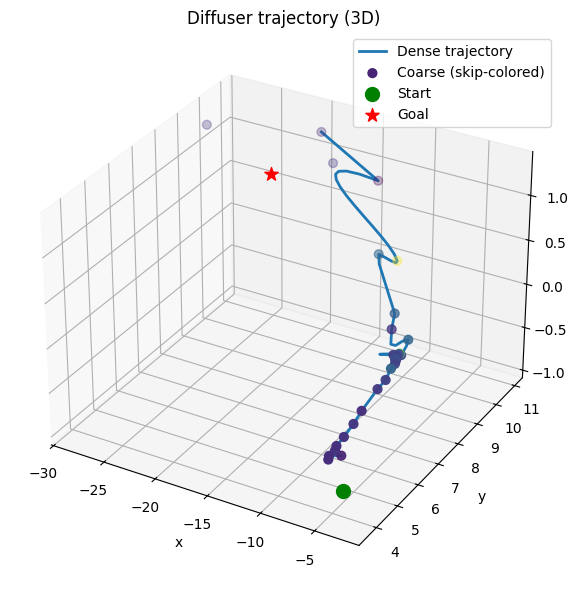

In [56]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

# Dense trajectory
ax.plot(
    pos_dense[:, 0],
    pos_dense[:, 1],
    pos_dense[:, 2],
    linewidth=2,
    label="Dense trajectory"
)

# Coarse waypoints
ax.scatter(
    coarse_pos[:, 0],
    coarse_pos[:, 1],
    coarse_pos[:, 2],
    c=coarse_skip,
    cmap="viridis",
    s=40,
    label="Coarse (skip-colored)"
)

# Start / goal
ax.scatter(*current[:3], c="green", s=100, marker="o", label="Start")
ax.scatter(*goal,        c="red",   s=100, marker="*", label="Goal")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Diffuser trajectory (3D)")
ax.legend()

plt.tight_layout()
plt.show()
